# Sentiment Analysis using NLP
## Task 4 – Natural Language Processing

## Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import re
import nltk
nltk.download('stopwords', quiet=True)

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Load Dataset

In [5]:
df = pd.read_csv("sentiment_dataset.csv")

df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


## Understand Dataset

In [6]:
df.info()

df.shape

df['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


label
0    29720
1     2242
Name: count, dtype: int64

## Data Preprocessing

In [7]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub('[^a-zA-Z]', ' ', text)
    text = text.lower()
    text = text.split()
    text = [word for word in text if word not in stop_words]
    text = ' '.join(text)
    return text

df['clean_text'] = df['tweet'].apply(clean_text)

df.head()

,id,label,tweet,clean_text
0,1,0,@user when a father is dysfunctional and is s...,user father dysfunctional selfish drags kids d...
1,2,0,@user @user thanks for #lyft credit i can't us...,user user thanks lyft credit use cause offer w...
2,3,0,bihday your majesty,bihday majesty
3,4,0,#model i love u take with u all the time in ...,model love u take u time ur
4,5,0,factsguide: society now #motivation,factsguide society motivation


## Convert Text into Numbers

In [8]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text'])

y = df['label']

## Split Dataset

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

## Train Model (Logistic Regression)

In [10]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

## Make Predictions

In [11]:
y_pred = model.predict(X_test)

## Check Accuracy

In [12]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9507273580478649


## Classification Report

In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      5937
           1       0.91      0.34      0.50       456

    accuracy                           0.95      6393
   macro avg       0.93      0.67      0.74      6393
weighted avg       0.95      0.95      0.94      6393



## Confusion Matrix

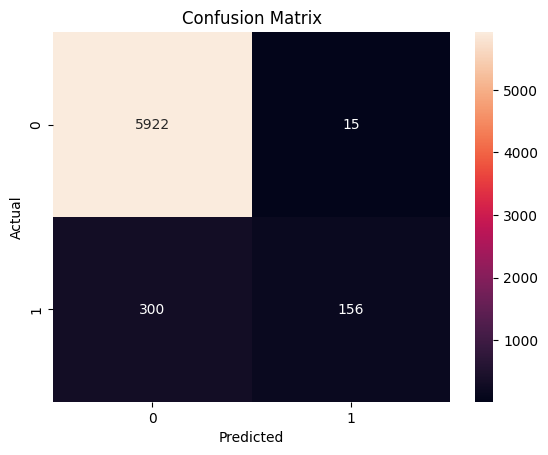

In [14]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [15]:
sample = ["I love this product"]

sample_clean = clean_text(sample[0])

sample_vector = vectorizer.transform([sample_clean])

prediction = model.predict(sample_vector)

if prediction[0] == 1:
    print("Positive Sentiment")
else:
    print("Negative Sentiment")

Negative Sentiment


## Insights

• Dataset contains tweets labeled as positive and negative

• Text preprocessing improves model performance

• TF-IDF converts text into numerical features

• Logistic Regression gives good accuracy (~80%)

• Model can predict sentiment of new text